## Imports

In [1]:
import os

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    TextVectorization,
    Embedding,
    Dense,
    SimpleRNN,
    LSTM,
    GRU,
    RNN,
    SimpleRNNCell,
    Bidirectional,
    Dropout,
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

I0000 00:00:1778410662.602295   16035 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778410662.649221   16035 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778410664.147980   16035 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 10)

In [3]:
if not os.path.exists("models"):
    os.makedirs("models")

In [4]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## Utils

In [5]:
def plot_history(history, title="Model Performance"):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="validation")
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="validation")
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [6]:
def build_model(rnn_type="SimpleRNN"):
    model = Sequential()

    model.add(Input(shape=(max_len,), dtype="int32"))
    model.add(Embedding(input_dim=max_tokens + 1, output_dim=128))

    if rnn_type == "SimpleRNN":
        model.add(Bidirectional(SimpleRNN(64)))
    elif rnn_type == "LSTM":
        model.add(Bidirectional(LSTM(64)))
    elif rnn_type == "GRU":
        model.add(Bidirectional(GRU(64)))

    model.add(Dropout(0.5))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [7]:
def predict(model, sample_texts, sample_x, sample_labels_true, num_samples, title):

    print("Generating predictions...")
    preds_model = model.predict(sample_x, verbose=0)

    for i in range(num_samples):
        text_snippet = sample_texts[i].replace("\n", " ")
        if len(text_snippet) > 80:
            text_snippet = text_snippet[:80] + "..."

        true_sentiment = "Positive" if sample_labels_true[i] == 1.0 else "Negative"

        model_val = preds_model[i][0]

        model_sentiment = "Positive" if model_val > 0.5 else "Negative"

        print(f"\n[Sample {i+1}] Text: '{text_snippet}'")
        print(f"  - True Label : {true_sentiment}")
        print(f"  - {title}  : {model_sentiment:<8} (Confidence: {model_val:.4f})")

## Dataload

In [8]:
print("Loading data from CSV...")
df = pd.read_csv("../data/IMDB Dataset.csv")

df.info()

Loading data from CSV...
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [9]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [10]:
texts = df["review"].astype(str).tolist()
labels = np.where(
    df["sentiment"].astype(str).str.lower().str.strip() == "positive", 1.0, 0.0
).astype(np.float32)

print("Splitting data into train, validation, and test sets...")
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

Splitting data into train, validation, and test sets...


In [11]:
max_tokens = 10000
max_len = 250

vectorize_layer = TextVectorization(
    max_tokens=max_tokens, output_mode="int", output_sequence_length=max_len
)

print("Adapting TextVectorization layer to the training vocabulary...")
vectorize_layer.adapt(train_texts)

print("Pre-vectorizing the text data...")
train_x = vectorize_layer(train_texts)
val_x = vectorize_layer(val_texts)
test_x = vectorize_layer(test_texts)

train_y = tf.constant(train_labels)
val_y = tf.constant(val_labels)
test_y = tf.constant(test_labels)

Adapting TextVectorization layer to the training vocabulary...


E0000 00:00:1778410666.939152   16035 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778410666.956607   16035 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Pre-vectorizing the text data...


## Training

In [12]:
epochs_to_run = 10
batch_size = 256

custom_reviews = [
    "This movie was an absolute triumph. The direction was brilliant and the acting was top notch.",
    "I regret spending money on this. The plot made no sense and it was incredibly boring.",
]

custom_reviews_vectorized = vectorize_layer(custom_reviews)

num_samples = 10
sample_texts = test_texts[:num_samples]
sample_labels_true = test_labels[:num_samples]
sample_x = vectorize_layer(sample_texts)

### SimpleRNN

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 188ms/step - accuracy: 0.6500 - loss: 0.6129 - val_accuracy: 0.7904 - val_loss: 0.4640
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 184ms/step - accuracy: 0.7886 - loss: 0.4749 - val_accuracy: 0.8038 - val_loss: 0.4561
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.7638 - loss: 0.5030 - val_accuracy: 0.8054 - val_loss: 0.4483
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 203ms/step - accuracy: 0.7955 - loss: 0.4565 - val_accuracy: 0.8012 - val_loss: 0.4924
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 178ms/step - accuracy: 0.8917 - loss: 0.2809 - val_accuracy: 0.8096 - val_loss: 0.5734
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.8508 - loss: 0.3486 - val_accuracy: 0.6980 - val_loss: 0.6240

Evaluating SimpleRNN on Test Data...
Test Accuracy: 0.8076


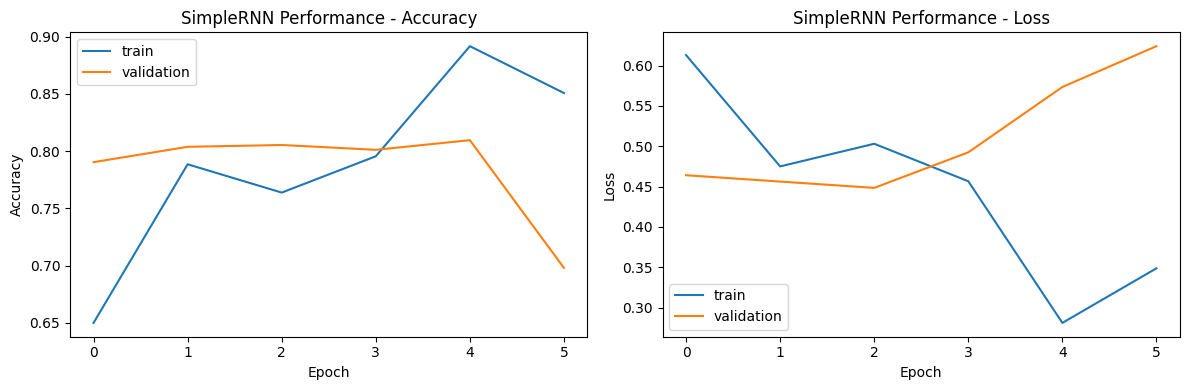

In [13]:
model_rnn = build_model(rnn_type="SimpleRNN")

early_stop_rnn = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
checkpoint_rnn = ModelCheckpoint(
    filepath="models/best_model_SimpleRNN.keras",
    monitor="val_loss",
    save_best_only=True,
)

history_rnn = model_rnn.fit(
    x=train_x,
    y=train_y,
    validation_data=(val_x, val_y),
    epochs=epochs_to_run,
    batch_size=batch_size,
    callbacks=[early_stop_rnn, checkpoint_rnn],
)

print(f"\nEvaluating SimpleRNN on Test Data...")
loss, acc = model_rnn.evaluate(test_x, test_y, batch_size=batch_size, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

plot_history(history_rnn, title="SimpleRNN Performance")

In [14]:
print(f"\nTest samples predictions:")
predict(
    model_rnn,
    sample_texts,
    sample_x,
    sample_labels_true,
    num_samples,
    title="SimpleRNN Prediction",
)

print(f"\nCustom Predictions:")
predictions = model_rnn.predict(custom_reviews_vectorized, verbose=0)
for review, pred in zip(custom_reviews, predictions):
    print(
        f"Review: '{review[:50]}...' -> {'Positive' if pred[0] > 0.5 else 'Negative'} ({pred[0]:.4f})"
    )


Test samples predictions:
Generating predictions...

[Sample 1] Text: 'the tortuous emotional impact is degrading, whether adult or adolescent the pers...'
  - True Label : Negative
  - SimpleRNN Prediction  : Negative (Confidence: 0.3479)

[Sample 2] Text: 'Anyone who knows anything about evolution wouldn't even need to see the film to ...'
  - True Label : Negative
  - SimpleRNN Prediction  : Negative (Confidence: 0.1333)

[Sample 3] Text: 'I'm glad I rented this movie for one reason: its shortcomings made me want to re...'
  - True Label : Negative
  - SimpleRNN Prediction  : Negative (Confidence: 0.3372)

[Sample 4] Text: 'Yes, the votes are in. This film may very well be the Plan 9 From Outer Space fo...'
  - True Label : Negative
  - SimpleRNN Prediction  : Positive (Confidence: 0.5093)

[Sample 5] Text: 'This mini-series is actually more entertaining than some others with much bigger...'
  - True Label : Negative
  - SimpleRNN Prediction  : Positive (Confidence: 0.9064)

[Sampl

### LSTM

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 373ms/step - accuracy: 0.7134 - loss: 0.5386 - val_accuracy: 0.8070 - val_loss: 0.4433
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - accuracy: 0.8765 - loss: 0.3149 - val_accuracy: 0.8652 - val_loss: 0.3418
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 372ms/step - accuracy: 0.9114 - loss: 0.2398 - val_accuracy: 0.8532 - val_loss: 0.3369
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - accuracy: 0.9129 - loss: 0.2368 - val_accuracy: 0.8652 - val_loss: 0.3341
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 365ms/step - accuracy: 0.8996 - loss: 0.2557 - val_accuracy: 0.8718 - val_loss: 0.4215
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 370ms/step - accuracy: 0.9343 - loss: 0.1851 - val_accuracy: 0.8694 - val_loss: 0.3943
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 375ms/step - accuracy: 0.9360 - loss: 0.1770 - val_accuracy: 0.8678 - val_loss: 0.3960

Evaluating LSTM on Test Data...
Test Accuracy: 0.8666


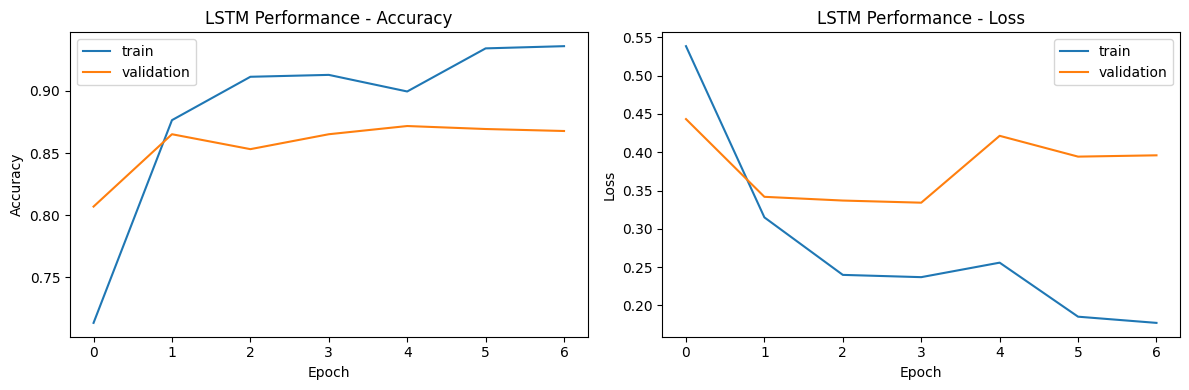

In [15]:
model_lstm = build_model(rnn_type="LSTM")

early_stop_lstm = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
checkpoint_lstm = ModelCheckpoint(
    filepath="models/best_model_LSTM.keras", monitor="val_loss", save_best_only=True
)

history_lstm = model_lstm.fit(
    x=train_x,
    y=train_y,
    validation_data=(val_x, val_y),
    epochs=epochs_to_run,
    batch_size=batch_size,
    callbacks=[early_stop_lstm, checkpoint_lstm],
)

print(f"\nEvaluating LSTM on Test Data...")
loss, acc = model_lstm.evaluate(test_x, test_y, batch_size=batch_size, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

plot_history(history_lstm, title="LSTM Performance")

In [16]:
print(f"\nTest samples predictions:")
predict(
    model_lstm,
    sample_texts,
    sample_x,
    sample_labels_true,
    num_samples,
    title="LSTM Prediction",
)

print(f"\nCustom Predictions:")
predictions = model_lstm.predict(custom_reviews_vectorized, verbose=0)
for review, pred in zip(custom_reviews, predictions):
    print(
        f"Review: '{review[:50]}...' -> {'Positive' if pred[0] > 0.5 else 'Negative'} ({pred[0]:.4f})"
    )


Test samples predictions:
Generating predictions...

[Sample 1] Text: 'the tortuous emotional impact is degrading, whether adult or adolescent the pers...'
  - True Label : Negative
  - LSTM Prediction  : Negative (Confidence: 0.0344)

[Sample 2] Text: 'Anyone who knows anything about evolution wouldn't even need to see the film to ...'
  - True Label : Negative
  - LSTM Prediction  : Negative (Confidence: 0.1191)

[Sample 3] Text: 'I'm glad I rented this movie for one reason: its shortcomings made me want to re...'
  - True Label : Negative
  - LSTM Prediction  : Negative (Confidence: 0.2158)

[Sample 4] Text: 'Yes, the votes are in. This film may very well be the Plan 9 From Outer Space fo...'
  - True Label : Negative
  - LSTM Prediction  : Negative (Confidence: 0.2763)

[Sample 5] Text: 'This mini-series is actually more entertaining than some others with much bigger...'
  - True Label : Negative
  - LSTM Prediction  : Positive (Confidence: 0.9550)

[Sample 6] Text: 'For those wit

### GRU

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 385ms/step - accuracy: 0.6203 - loss: 0.6369 - val_accuracy: 0.7914 - val_loss: 0.4599
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 406ms/step - accuracy: 0.8459 - loss: 0.3732 - val_accuracy: 0.8414 - val_loss: 0.3754
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 365ms/step - accuracy: 0.8984 - loss: 0.2681 - val_accuracy: 0.7988 - val_loss: 0.4358
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 373ms/step - accuracy: 0.9136 - loss: 0.2358 - val_accuracy: 0.8480 - val_loss: 0.3831
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 397ms/step - accuracy: 0.9237 - loss: 0.2109 - val_accuracy: 0.8746 - val_loss: 0.3877

Evaluating GRU on Test Data...
Test Accuracy: 0.8476


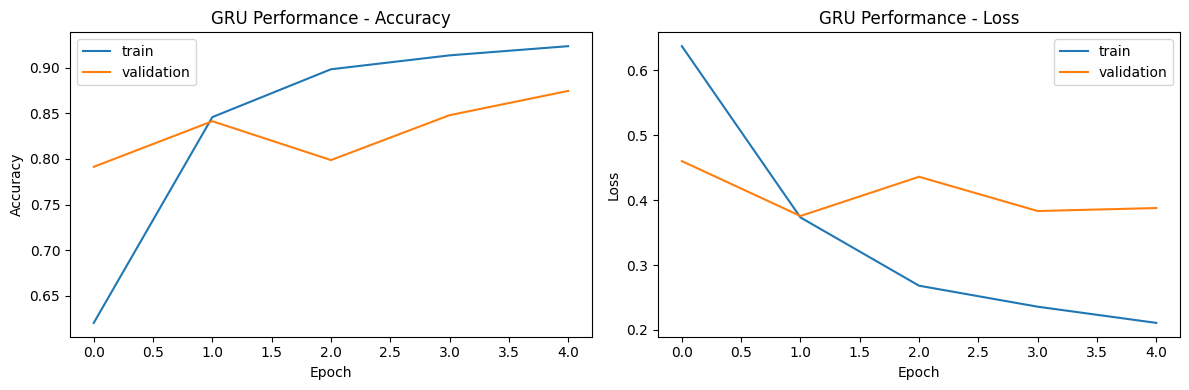

In [17]:
model_gru = build_model(rnn_type="GRU")

early_stop_gru = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
checkpoint_gru = ModelCheckpoint(
    filepath="models/best_model_GRU.keras", monitor="val_loss", save_best_only=True
)

history_gru = model_gru.fit(
    x=train_x,
    y=train_y,
    validation_data=(val_x, val_y),
    epochs=epochs_to_run,
    batch_size=batch_size,
    callbacks=[early_stop_gru, checkpoint_gru],
)

print(f"\nEvaluating GRU on Test Data...")
loss, acc = model_gru.evaluate(test_x, test_y, batch_size=batch_size, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

plot_history(history_gru, title="GRU Performance")

In [18]:
print(f"\nTest samples predictions:")
predict(
    model_gru,
    sample_texts,
    sample_x,
    sample_labels_true,
    num_samples,
    title="GRU Prediction",
)

print(f"\nCustom Predictions:")
predictions = model_gru.predict(custom_reviews_vectorized, verbose=0)
for review, pred in zip(custom_reviews, predictions):
    print(
        f"Review: '{review[:50]}...' -> {'Positive' if pred[0] > 0.5 else 'Negative'} ({pred[0]:.4f})"
    )


Test samples predictions:
Generating predictions...

[Sample 1] Text: 'the tortuous emotional impact is degrading, whether adult or adolescent the pers...'
  - True Label : Negative
  - GRU Prediction  : Negative (Confidence: 0.0699)

[Sample 2] Text: 'Anyone who knows anything about evolution wouldn't even need to see the film to ...'
  - True Label : Negative
  - GRU Prediction  : Negative (Confidence: 0.0595)

[Sample 3] Text: 'I'm glad I rented this movie for one reason: its shortcomings made me want to re...'
  - True Label : Negative
  - GRU Prediction  : Negative (Confidence: 0.1423)

[Sample 4] Text: 'Yes, the votes are in. This film may very well be the Plan 9 From Outer Space fo...'
  - True Label : Negative
  - GRU Prediction  : Positive (Confidence: 0.8659)

[Sample 5] Text: 'This mini-series is actually more entertaining than some others with much bigger...'
  - True Label : Negative
  - GRU Prediction  : Positive (Confidence: 0.9014)

[Sample 6] Text: 'For those with acc